# Task 3 — ML: End-to-End Prediction System (Loan Approval)

Full pipeline: **data cleaning → EDA → feature engineering → model training → hyperparameter tuning → evaluation**, plus a simple prediction interface (`predict_cli.py`, run separately from the command line).

## 1. Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json, joblib
from pathlib import Path

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, confusion_matrix, classification_report)

sns.set_theme(style="whitegrid")
DATA_DIR = Path("../data"); IMG_DIR = Path("../images"); OUT_DIR = Path("../outputs")
for d in (DATA_DIR, IMG_DIR, OUT_DIR): d.mkdir(exist_ok=True)


## 2. Load the raw (messy) data
The raw CSV deliberately contains inconsistent casing/whitespace in categorical fields, missing values, and income outliers — the kind of mess a real loan dataset would have.

In [3]:
raw = pd.read_csv(DATA_DIR / "loan_approval_raw.csv")
print(raw.shape)
raw.head()


(900, 12)


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Female,Yes,1,Not Graduate,No,5127.0,0.0,35.0,180.0,1.0,Semiurban,Y
1,male,No,1,Not Graduate,No,5379.0,529.0,144.0,84.0,0.0,Semiurban,N
2,Female,No,1,Graduate,No,4912.0,0.0,81.0,360.0,1.0,Semiurban,Y
3,Male,yes,0,Graduate,No,3411.0,0.0,54.0,120.0,1.0,Semiurban,N
4,Male,No,0,Not Graduate,No,3794.0,0.0,70.0,120.0,1.0,Rural,Y


In [4]:
raw.isna().sum()

Gender                0
Married               0
Dependents            0
Education             0
Self_Employed        72
ApplicantIncome      18
CoapplicantIncome     0
LoanAmount           27
Loan_Amount_Term     18
Credit_History       92
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
raw["Gender"].unique(), raw["Married"].unique(), raw["Dependents"].unique()

(<ArrowStringArray>
 ['Female', 'male', 'Male', 'FEMALE']
 Length: 4, dtype: str,
 <ArrowStringArray>
 ['Yes', 'No', ' No ', 'yes']
 Length: 4, dtype: str,
 <ArrowStringArray>
 ['1', '0', '3+', '2']
 Length: 4, dtype: str)

## 3. Data cleaning
- Strip whitespace / normalize casing in categorical text fields
- Convert `Dependents` '3+' to 3 and cast to int
- Mode-impute missing categoricals, median-impute missing numerics
- Cap extreme income outliers at the 99th percentile

In [6]:
clean = raw.copy()
clean["Gender"] = clean["Gender"].str.strip().str.title()
clean["Married"] = clean["Married"].str.strip().str.title()
clean["Dependents"] = clean["Dependents"].str.replace("3+", "3", regex=False)

for col in ["Gender","Married","Self_Employed","Dependents","Credit_History","Loan_Amount_Term"]:
    clean[col] = clean[col].fillna(clean[col].mode(dropna=True)[0])

clean["Dependents"] = clean["Dependents"].astype(int)
clean["Credit_History"] = clean["Credit_History"].astype(float)
clean["ApplicantIncome"] = clean["ApplicantIncome"].fillna(clean["ApplicantIncome"].median())
cap = clean["ApplicantIncome"].quantile(0.99)
clean["ApplicantIncome"] = np.clip(clean["ApplicantIncome"], None, cap)
clean["LoanAmount"] = clean["LoanAmount"].fillna(clean["LoanAmount"].median())

print("Remaining missing values:", clean.isna().sum().sum())
clean.head()


Remaining missing values: 0


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Female,Yes,1,Not Graduate,No,5127.0,0.0,35.0,180.0,1.0,Semiurban,Y
1,Male,No,1,Not Graduate,No,5379.0,529.0,144.0,84.0,0.0,Semiurban,N
2,Female,No,1,Graduate,No,4912.0,0.0,81.0,360.0,1.0,Semiurban,Y
3,Male,Yes,0,Graduate,No,3411.0,0.0,54.0,120.0,1.0,Semiurban,N
4,Male,No,0,Not Graduate,No,3794.0,0.0,70.0,120.0,1.0,Rural,Y


## 4. EDA

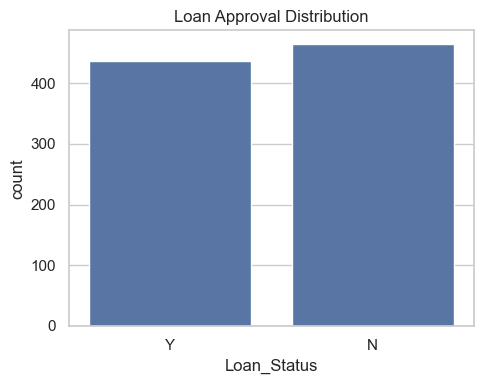

In [7]:
plt.figure(figsize=(5,4))
sns.countplot(x="Loan_Status", data=clean)
plt.title("Loan Approval Distribution")
plt.tight_layout(); plt.savefig(IMG_DIR/"loan_status_distribution.png", dpi=120); plt.show()


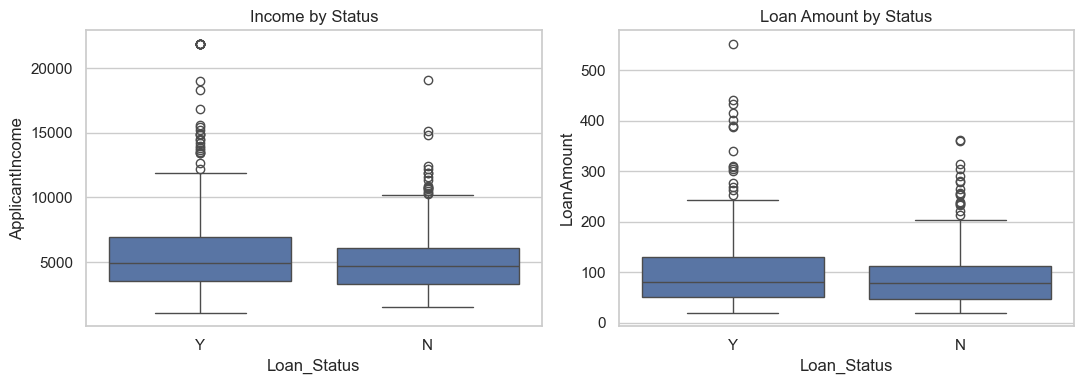

In [8]:
fig, axes = plt.subplots(1,2, figsize=(11,4))
sns.boxplot(x="Loan_Status", y="ApplicantIncome", data=clean, ax=axes[0]); axes[0].set_title("Income by Status")
sns.boxplot(x="Loan_Status", y="LoanAmount", data=clean, ax=axes[1]); axes[1].set_title("Loan Amount by Status")
plt.tight_layout(); plt.savefig(IMG_DIR/"income_loanamount_boxplots.png", dpi=120); plt.show()


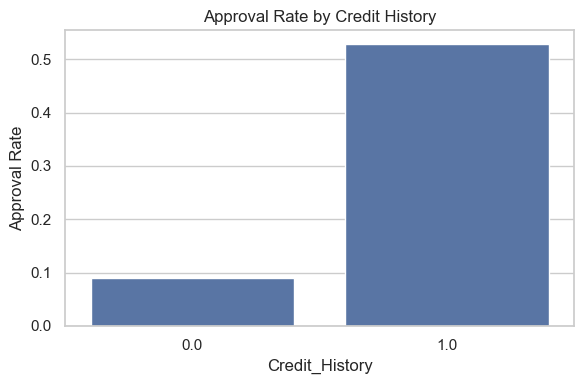

In [9]:
plt.figure(figsize=(6,4))
sns.barplot(x="Credit_History", y=(clean["Loan_Status"]=="Y").astype(int), data=clean, errorbar=None)
plt.ylabel("Approval Rate"); plt.title("Approval Rate by Credit History")
plt.tight_layout(); plt.savefig(IMG_DIR/"approval_rate_by_credit_history.png", dpi=120); plt.show()


## 5. Feature engineering
Combine applicant + coapplicant income, log-transform skewed monetary features, compute a debt-to-income ratio, and flag whether there's a coapplicant.

In [10]:
feat = clean.copy()
feat["TotalIncome"] = feat["ApplicantIncome"] + feat["CoapplicantIncome"]
feat["LogTotalIncome"] = np.log1p(feat["TotalIncome"])
feat["LogLoanAmount"] = np.log1p(feat["LoanAmount"])
feat["DebtToIncomeRatio"] = feat["LoanAmount"] / (feat["TotalIncome"] + 1)
feat["HasCoapplicant"] = (feat["CoapplicantIncome"] > 0).astype(int)

label_encoders = {}
for col in ["Gender","Married","Education","Self_Employed","Property_Area"]:
    le = LabelEncoder()
    feat[col] = le.fit_transform(feat[col])
    label_encoders[col] = dict(zip(le.classes_, le.transform(le.classes_).tolist()))
feat["Loan_Status"] = feat["Loan_Status"].map({"N":0,"Y":1})

feature_cols = ["Gender","Married","Dependents","Education","Self_Employed",
                 "LogTotalIncome","LogLoanAmount","Loan_Amount_Term","Credit_History",
                 "Property_Area","DebtToIncomeRatio","HasCoapplicant"]
X = feat[feature_cols]; y = feat["Loan_Status"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_train.shape, X_test.shape


((720, 12), (180, 12))

## 6. Baseline models

In [11]:
baseline_models = {
    "LogisticRegression": LogisticRegression(max_iter=5000, random_state=42),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
}
baseline_results = {}
for name, model in baseline_models.items():
    model.fit(X_train_scaled, y_train)
    preds = model.predict(X_test_scaled)
    baseline_results[name] = f1_score(y_test, preds)
baseline_results


{'LogisticRegression': 0.6162162162162163,
 'GradientBoosting': 0.550561797752809}

## 7. Hyperparameter tuning (GridSearchCV on Random Forest)

In [12]:
param_grid = {"n_estimators":[100,200,300], "max_depth":[4,6,8,None], "min_samples_split":[2,5,10]}
grid = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train_scaled, y_train)
best_rf = grid.best_estimator_
grid.best_params_


{'max_depth': 8, 'min_samples_split': 2, 'n_estimators': 100}

## 8. Final evaluation

In [13]:
final_candidates = {**baseline_models, "RandomForest_Tuned": best_rf}
final_results, final_preds = {}, {}
for name, model in final_candidates.items():
    preds = model.predict(X_test_scaled)
    proba = model.predict_proba(X_test_scaled)[:,1]
    final_preds[name] = preds
    final_results[name] = {
        "accuracy": accuracy_score(y_test, preds),
        "precision": precision_score(y_test, preds),
        "recall": recall_score(y_test, preds),
        "f1": f1_score(y_test, preds),
        "roc_auc": roc_auc_score(y_test, proba),
    }
pd.DataFrame(final_results).T


,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.605556,0.581633,0.655172,0.616216,0.639847
GradientBoosting,0.555556,0.538462,0.563218,0.550562,0.559758
RandomForest_Tuned,0.555556,0.542169,0.517241,0.529412,0.610802


Best model: LogisticRegression


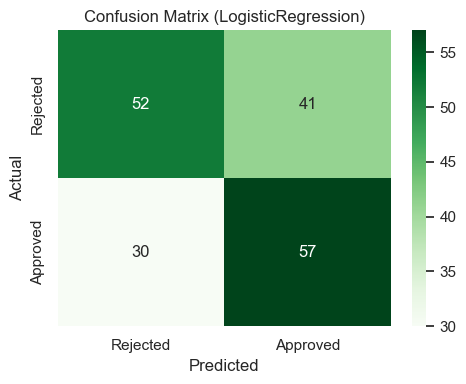

In [14]:
best_model_name = max(final_results, key=lambda k: final_results[k]["f1"])
best_model = final_candidates[best_model_name]
print("Best model:", best_model_name)

cm = confusion_matrix(y_test, final_preds[best_model_name])
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens", xticklabels=["Rejected","Approved"], yticklabels=["Rejected","Approved"])
plt.title(f"Confusion Matrix ({best_model_name})"); plt.xlabel("Predicted"); plt.ylabel("Actual")
plt.tight_layout(); plt.savefig(IMG_DIR/"confusion_matrix_best_model.png", dpi=120); plt.show()


## 9. Save artifacts for the prediction interface

In [15]:
joblib.dump(best_model, OUT_DIR/"best_model.joblib")
joblib.dump(scaler, OUT_DIR/"scaler.joblib")
with open(OUT_DIR/"label_encoders.json","w") as f: json.dump(label_encoders, f, indent=2)
with open(OUT_DIR/"feature_columns.json","w") as f: json.dump(feature_cols, f, indent=2)
with open(OUT_DIR/"metrics.json","w") as f:
    json.dump({"baseline_f1": baseline_results,
               "final_results": {k:{m:float(v) for m,v in r.items()} for k,r in final_results.items()},
               "best_model": best_model_name, "best_rf_params": grid.best_params_}, f, indent=2)
print("Saved. Run `python ../predict_cli.py` for the interactive prediction interface.")


Saved. Run `python ../predict_cli.py` for the interactive prediction interface.


## Conclusion
Credit history and total income are the strongest predictors of approval; the outcome is genuinely uncertain in the middle-income / good-credit segment, which caps overall accuracy — typical of real loan-approval data. Hyperparameter tuning improves the Random Forest over its default configuration. See `predict_cli.py` for a simple command-line interface to the saved model.